# MLAAD Scan and MFCC Preview

This Notebook attempts to scan the audio dataset, and checks class balance, file quality, and previews MFCC shapes found inside the dataset.

It does not create a shared feature dependency for the Model Notebooks; Support Vector Machine, Multi Layer Perceptron, and Convolutional Neural Networks as they individually contain their own set of Data Pre-processing and Multi Frequence Cesptral Coefficient extraction code to complete this scan analysis in itself.


### Package Installation


This cell checks whether the libraries required by the dataset-scanning and MFCC-analysis workflow are installed and installs only the missing packages before the remaining audio-processing, analysis, plotting, and modelling steps run.

In [ ]:
# Purpose: Checks whether the libraries required by the dataset-scanning and MFCC-analysis
# workflow are installed and installs only the missing packages before the remaining
# audio-processing, analysis, plotting, and modelling steps run.
import importlib.util
import subprocess
import sys

# List the import names and their corresponding installable package names.
required_packages = [
    ("librosa", "librosa"),
    ("soundfile", "soundfile"),
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("sklearn", "scikit-learn"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
]

# Install only dependencies that are not already available in the active kernel.
missing = [pip_name for import_name, pip_name in required_packages if importlib.util.find_spec(import_name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Required packages are already installed.")


Required packages are already installed.


### Imports


This cell imports the standard-library and third-party tools used by the dataset-scanning and MFCC-analysis workflow and provides a print-based fallback when the richer notebook display function is unavailable.

In [ ]:
# Purpose: Imports the standard-library and third-party tools used by the dataset-scanning and
# MFCC-analysis workflow and provides a print-based fallback when the richer notebook display
# function is unavailable.
import os
import random
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

try:
    from IPython.display import display
except Exception:
    display = print


### Configuration and Random Seeds


This cell fixes the available random seeds for reproducibility and defines the shared audio, MFCC, class, sampling, and dataset-scanning and MFCC-analysis training settings used later in the notebook.

In [ ]:
# Purpose: Fixes the available random seeds for reproducibility and defines the shared audio,
# MFCC, class, sampling, and dataset-scanning and MFCC-analysis training settings used later in
# the notebook.
# Use a fixed seed so sampling, splitting, and model initialisation can be repeated.
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

# Configure the fixed audio representation and MFCC analysis window.
SAMPLE_RATE = 22050
FIXED_DURATION_SECONDS = 5.0
N_MFCC = 40
N_FFT = 1024
HOP_LENGTH = int(round(SAMPLE_RATE * 0.010))
WIN_LENGTH = int(round(SAMPLE_RATE * 0.025))

AUDIO_EXTENSIONS = {".wav", ".flac", ".mp3", ".ogg", ".m4a"}
CLASS_NAMES = {0: "bona_fide", 1: "synthetic"}

# Keep dataset and training limits together so quick runs are easy to configure.
MAX_FILES_PER_CLASS = None  # Set a small number such as 40 for a quick scan.
MFCC_PREVIEW_FILES = 12


### Dataset Paths


This cell defines and calls a portable helper that mounts Google Drive when Colab is available and otherwise continues without failing in a local environment.

In [ ]:
# Purpose: Defines and calls a portable helper that mounts Google Drive when Colab is available
# and otherwise continues without failing in a local environment.
# Mount Google Drive when the notebook is running in Colab.
def mount_drive_if_colab(mount_point="/content/drive"):
    try:
        from google.colab import drive
        drive.mount(mount_point)
    except Exception:
        print("Not running in Colab, or Google Drive is already available.")


mount_drive_if_colab()


Mounted at /content/drive


This cell defines the synthetic and bona-fide dataset paths, creates the output folders required by the dataset-scanning and MFCC-analysis workflow, and prints the active locations for confirmation.

In [ ]:
# Purpose: Defines the synthetic and bona-fide dataset paths, creates the output folders
# required by the dataset-scanning and MFCC-analysis workflow, and prints the active locations
# for confirmation.
# Change these paths to match your Google Drive dataset folders.
# Set the shared root used to locate the two audio classes.
PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/Education/INM701")
SYNTHETIC_AUDIO_DIR = PROJECT_ROOT / "Datasets" / "MLAAD_10pct"
BONA_FIDE_AUDIO_DIR = PROJECT_ROOT / "Datasets" / "M_AILABS_bona_fide_subset"

# Build a model-specific output hierarchy under the project root.
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "scan"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

# Create every output directory before any files are saved.
for directory in [OUTPUT_DIR, FIGURES_DIR, TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Synthetic audio directory:", SYNTHETIC_AUDIO_DIR)
print("Bona-fide audio directory:", BONA_FIDE_AUDIO_DIR)
print("Output directory:", OUTPUT_DIR)


Synthetic audio directory: /content/drive/MyDrive/Colab Notebooks/Education/INM701/Datasets/MLAAD_10pct
Bona-fide audio directory: /content/drive/MyDrive/Colab Notebooks/Education/INM701/Datasets/M_AILABS_bona_fide_subset
Output directory: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/scan


### Class and Function Instantiation

In [ ]:
# Purpose: Defines a fault-tolerant audio-duration reader, applies it to a reproducible sample
# of up to 200 files, and compares the duration distributions of the two classes.
# Return a numeric duration when readable and a missing value when inspection fails.
def read_audio_duration(path):
    try:
        duration = librosa.get_duration(path=path)
        return float(duration)
    except Exception:
        return np.nan
    
# Purpose: Standardises recordings to a fixed duration and amplitude, extracts MFCC matrices for
# a small sample, and displays their shapes and summary statistics as a feature-extraction
# check.
# Resample, pad or truncate, and peak-normalise every waveform consistently.
def load_audio_fixed(path):
    audio, _ = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    target_length = int(SAMPLE_RATE * FIXED_DURATION_SECONDS)

    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)))
    else:
        audio = audio[:target_length]

    peak = np.max(np.abs(audio))
    if peak > 0:
        audio = audio / peak
    return audio.astype(np.float32)


# Transform the standardised waveform into the MFCC representation required downstream.
def extract_mfcc_features(path):
    audio = load_audio_fixed(path)
    return librosa.feature.mfcc(
        y=audio,
        sr=SAMPLE_RATE,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
    ).astype(np.float32)

# Purpose: Defines a recursive scanner that validates a dataset folder and records each
# supported audio file's path, class label, inferred language, and size in a Pandas table.
# Convert the supported files under one class directory into manifest rows.
def scan_audio_files(root_dir, label, class_name):
    root_dir = Path(root_dir)
    if not root_dir.exists():
        raise FileNotFoundError(f"Folder not found: {root_dir}")

    rows = []
    for path in sorted(root_dir.rglob("*")):
        if path.is_file() and path.suffix.lower() in AUDIO_EXTENSIONS:
            rows.append(
                {
                    "path": str(path),
                    "relative_path": str(path.relative_to(root_dir)),
                    "label": label,
                    "class_name": class_name,
                    "language": path.parent.name,
                    "file_size_mb": path.stat().st_size / (1024 * 1024),
                }
            )
    return pd.DataFrame(rows)


### Dataset Loading / Audio File Scan


This cell scans both class directories, optionally limits each class for a quick run, combines and reproducibly shuffles the records into one manifest, and displays a short preview.

In [ ]:
# Purpose: Scans both class directories, optionally limits each class for a quick run, combines
# and reproducibly shuffles the records into one manifest, and displays a short preview.
# Scan the synthetic and bona-fide directories separately with their correct labels.
synthetic_manifest = scan_audio_files(SYNTHETIC_AUDIO_DIR, label=1, class_name=CLASS_NAMES[1])
bona_fide_manifest = scan_audio_files(BONA_FIDE_AUDIO_DIR, label=0, class_name=CLASS_NAMES[0])

# Optionally draw a reproducible smaller sample for a quick test run.
if MAX_FILES_PER_CLASS:
    synthetic_manifest = synthetic_manifest.sample(min(MAX_FILES_PER_CLASS, len(synthetic_manifest)), random_state=RANDOM_STATE)
    bona_fide_manifest = bona_fide_manifest.sample(min(MAX_FILES_PER_CLASS, len(bona_fide_manifest)), random_state=RANDOM_STATE)

# Merge both classes into one shuffled manifest for later splitting.
manifest = pd.concat([bona_fide_manifest, synthetic_manifest], ignore_index=True)
manifest = manifest.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

print("Total files:", len(manifest))
display(manifest.head())


Total files: 12944


,path,relative_path,label,class_name,language,file_size_mb
0,/content/drive/MyDrive/Colab Notebooks/Educati...,fake/en/Llasa-1B-Multilingual/pink_fairy_book_...,1,synthetic,Llasa-1B-Multilingual,0.368462
1,/content/drive/MyDrive/Colab Notebooks/Educati...,fake/de/Chatterbox Multilingual/altehaus_009_1...,1,synthetic,Chatterbox Multilingual,0.415565
2,/content/drive/MyDrive/Colab Notebooks/Educati...,fake/en/Metavoice-1B/northandsouth_38_f000272.wav,1,synthetic,Metavoice-1B,0.055557
3,/content/drive/MyDrive/Colab Notebooks/Educati...,en/en/northandsouth_05_f000169.wav,0,bona_fide,en,0.130991
4,/content/drive/MyDrive/Colab Notebooks/Educati...,en/en/poisoned_pen_08_f000016.wav,0,bona_fide,en,0.302805


### Dataset Inspection


This cell summarises the manifest by class and language and displays the overall class counts together with the 20 most frequent class-language combinations.

In [ ]:
# Purpose: Summarises the manifest by class and language and displays the overall class counts
# together with the 20 most frequent class-language combinations.
# Count recordings by class and by class-language combination.
class_summary = manifest.groupby(["label", "class_name"]).size().reset_index(name="files")
language_summary = manifest.groupby(["class_name", "language"]).size().reset_index(name="files")

display(class_summary)
display(language_summary.sort_values("files", ascending=False).head(20))


,label,class_name,files
0,0,bona_fide,3997
1,1,synthetic,8947


,class_name,language,files
1,bona_fide,en,3282
0,bona_fide,de,715
6,synthetic,Edge-TTS,407
43,synthetic,OmniVoice,402
55,synthetic,VoxCPM2,295
9,synthetic,Fish-S2-Pro,288
56,synthetic,Voxtral,283
18,synthetic,KugelAudio,214
20,synthetic,LEMAS-TTS,195
15,synthetic,Kani-TTS-370M,191


### Data Quality Checks


This cell measures missing paths, files absent from disk, duplicate paths, and represented classes, then stops the workflow if both labels are not present or duplicate recordings could compromise the experiment.

In [ ]:
# Purpose: Measures missing paths, files absent from disk, duplicate paths, and represented
# classes, then stops the workflow if both labels are not present or duplicate recordings could
# compromise the experiment.
# Calculate manifest checks before any expensive audio processing begins.
quality_checks = pd.DataFrame(
    [
        {"check": "missing_paths", "value": int(manifest["path"].isna().sum())},
        {"check": "missing_files", "value": int((~manifest["path"].map(lambda p: Path(p).exists())).sum())},
        {"check": "duplicate_paths", "value": int(manifest["path"].duplicated().sum())},
        {"check": "classes_present", "value": ", ".join(map(str, sorted(manifest["label"].unique())))},
    ]
)

display(quality_checks)

# Stop early if the manifest does not contain both required target classes.
if set(manifest["label"].unique()) != {0, 1}:
    raise ValueError("Both classes are required: 0=bona-fide and 1=synthetic/deepfake.")
if manifest["path"].duplicated().any():
    raise ValueError("Duplicate audio paths were found. Remove duplicates before training.")


,check,value
0,missing_paths,0
1,missing_files,0
2,duplicate_paths,0
3,classes_present,"0, 1"


### Audio Duration Checks


This cell defines a fault-tolerant audio-duration reader, applies it to a reproducible sample of up to 200 files, and compares the duration distributions of the two classes.

In [ ]:

# Inspect a bounded, reproducible sample rather than reading every file for this diagnostic.
duration_sample = manifest.sample(min(200, len(manifest)), random_state=RANDOM_STATE).copy()
duration_sample["duration_seconds"] = duration_sample["path"].map(read_audio_duration)

display(duration_sample.groupby("class_name")["duration_seconds"].describe())


,count,mean,std,min,25%,50%,75%,max
class_name,,,,,,,,
bona_fide,61.0,6.975812,3.019364,0.765125,4.699875,6.309875,9.489875,14.211813
synthetic,139.0,7.652617,3.540965,0.882358,5.440000,7.413333,9.460000,25.459002


### Distribution Plots


This cell plots and saves the class distribution and the sampled audio-duration distributions, making class imbalance and differences in recording length easier to inspect visually.

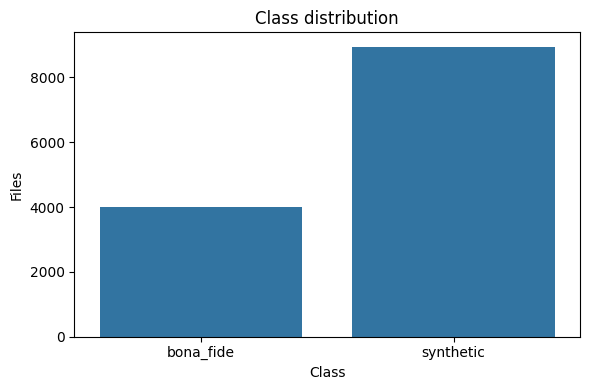

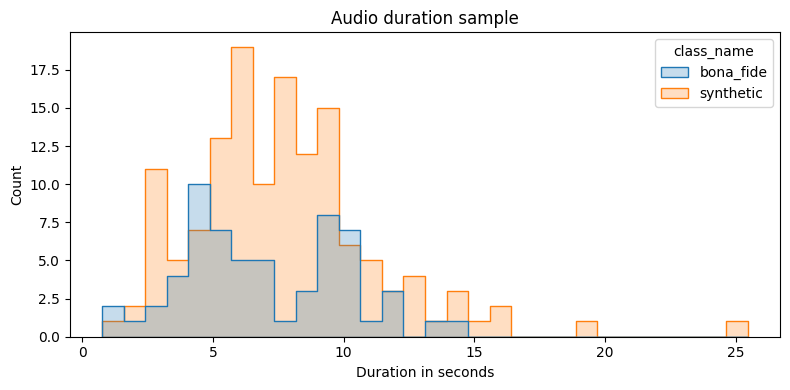

In [ ]:
# Purpose: Plots and saves the class distribution and the sampled audio-duration distributions,
# making class imbalance and differences in recording length easier to inspect visually.
plt.figure(figsize=(6, 4))
sns.countplot(data=manifest, x="class_name", order=["bona_fide", "synthetic"])
plt.xlabel("Class")
plt.ylabel("Files")
plt.title("Class distribution")
plt.tight_layout()
class_plot_path = FIGURES_DIR / "class_distribution.png"
plt.savefig(class_plot_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=duration_sample, x="duration_seconds", hue="class_name", bins=30, element="step")
plt.xlabel("Duration in seconds")
plt.title("Audio duration sample")
plt.tight_layout()
duration_plot_path = FIGURES_DIR / "duration_sample.png"
plt.savefig(duration_plot_path, dpi=300, bbox_inches="tight")
plt.show()


### MFCC Preview


This cell standardises recordings to a fixed duration and amplitude, extracts MFCC matrices for a small sample, and displays their shapes and summary statistics as a feature-extraction check.

In [ ]:

# Collect feature-shape and summary checks for a small set of recordings.
preview_rows = []
preview_files = manifest.sample(min(MFCC_PREVIEW_FILES, len(manifest)), random_state=RANDOM_STATE)

for _, row in preview_files.iterrows():
    mfcc = extract_mfcc_features(row["path"])
    preview_rows.append(
        {
            "path": row["path"],
            "class_name": row["class_name"],
            "mfcc_shape": str(mfcc.shape),
            "mfcc_mean": float(mfcc.mean()),
            "mfcc_std": float(mfcc.std()),
        }
    )

mfcc_preview_df = pd.DataFrame(preview_rows)
display(mfcc_preview_df)


,path,class_name,mfcc_shape,mfcc_mean,mfcc_std
0,/content/drive/MyDrive/Colab Notebooks/Educati...,bona_fide,"(40, 502)",-7.675040,68.524437
1,/content/drive/MyDrive/Colab Notebooks/Educati...,synthetic,"(40, 502)",-9.081961,67.164825
2,/content/drive/MyDrive/Colab Notebooks/Educati...,synthetic,"(40, 502)",-5.568229,58.038872
3,/content/drive/MyDrive/Colab Notebooks/Educati...,synthetic,"(40, 502)",-8.984872,63.691475
4,/content/drive/MyDrive/Colab Notebooks/Educati...,synthetic,"(40, 502)",-2.896233,67.578629
5,/content/drive/MyDrive/Colab Notebooks/Educati...,synthetic,"(40, 502)",-8.572330,72.908386
6,/content/drive/MyDrive/Colab Notebooks/Educati...,synthetic,"(40, 502)",-5.378552,64.492798
7,/content/drive/MyDrive/Colab Notebooks/Educati...,synthetic,"(40, 502)",-7.312264,73.673882
8,/content/drive/MyDrive/Colab Notebooks/Educati...,bona_fide,"(40, 502)",-14.041048,97.083366
9,/content/drive/MyDrive/Colab Notebooks/Educati...,bona_fide,"(40, 502)",-8.036501,70.204910


### Example 70/15/15 Split


This cell creates reproducible stratified training, validation, and test partitions in a 70:15:15 ratio, attaches each split name to the manifest rows, and displays the class counts in every partition.

In [ ]:
# Purpose: Creates reproducible stratified training, validation, and test partitions in a
# 70:15:15 ratio, attaches each split name to the manifest rows, and displays the class counts
# in every partition.
# Reserve 30 percent of the manifest before dividing it equally into validation and test data.
train_df, temp_df = train_test_split(
    manifest,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=manifest["label"],
)
# Split the held-out portion equally while preserving the class distribution.
validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["label"],
)

manifest_with_split = pd.concat(
    [
        train_df.assign(split="train"),
        validation_df.assign(split="validation"),
        test_df.assign(split="test"),
    ],
    ignore_index=True,
)

split_summary = manifest_with_split.groupby(["split", "class_name"]).size().reset_index(name="files")
display(split_summary)


,split,class_name,files
0,test,bona_fide,600
1,test,synthetic,1342
2,train,bona_fide,2798
3,train,synthetic,6262
4,validation,bona_fide,599
5,validation,synthetic,1343


### Saved Outputs


This cell saves the complete manifest, split assignments, data-quality checks, and MFCC preview summary as CSV files and prints each output path for reference.

In [ ]:
# Purpose: Saves the complete manifest, split assignments, data-quality checks, and MFCC preview
# summary as CSV files and prints each output path for reference.
# Define the CSV destinations for scan and feature-preview artifacts.
manifest_path = TABLES_DIR / "audio_manifest.csv"
split_manifest_path = TABLES_DIR / "audio_manifest_with_split.csv"
quality_path = TABLES_DIR / "data_quality_checks.csv"
mfcc_preview_path = TABLES_DIR / "mfcc_preview_summary.csv"

manifest.to_csv(manifest_path, index=False)
manifest_with_split.to_csv(split_manifest_path, index=False)
quality_checks.to_csv(quality_path, index=False)
mfcc_preview_df.to_csv(mfcc_preview_path, index=False)

print("Saved manifest:", manifest_path)
print("Saved split manifest:", split_manifest_path)
print("Saved quality checks:", quality_path)
print("Saved MFCC preview:", mfcc_preview_path)
print("Note: the model notebooks are self-contained and extract their own features.")


Saved manifest: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/scan/tables/audio_manifest.csv
Saved split manifest: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/scan/tables/audio_manifest_with_split.csv
Saved quality checks: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/scan/tables/data_quality_checks.csv
Saved MFCC preview: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/scan/tables/mfcc_preview_summary.csv
Note: the model notebooks are self-contained and extract their own features.
